## Load Dataset

In [1]:
!pip install -U datasets huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import datasets
from tqdm import tqdm
import numpy as np
import pandas as pd
from tokenizers import Tokenizer
import requests

In [3]:
dataset = datasets.load_dataset("wmt/wmt14", "de-en", split="train")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
df = pd.DataFrame(dataset["translation"])

In [5]:
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["de_len"] = df["de"].apply(lambda x: len(x.split()))

In [6]:
df.drop(df[df["en_len"] > 100].index, inplace=True)
df.drop(df[df["de_len"] > 100].index, inplace=True)

<Axes: ylabel='Frequency'>

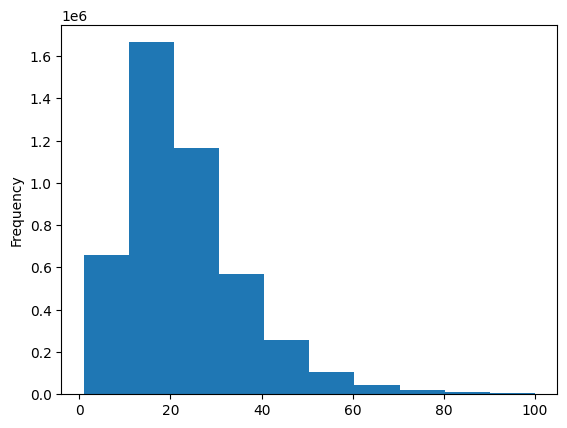

In [7]:
df["en_len"].plot(kind="hist", bins=10)

In [8]:
from sklearn.model_selection import train_test_split
def sample(df, size, val_split):
    num_bins = 10  # increase/decrease depending on precision vs sample size tradeoff
    df['bin'] = pd.cut(df['en_len'], bins=num_bins)
    sampled_df = (
        df.groupby('bin', group_keys=False)
        .apply(lambda x: x.sample(frac=size / len(df), random_state=42))
    )
    train_df, temp_df = train_test_split(
        sampled_df,
        test_size=val_split,  # 20% goes to val+test
        stratify=sampled_df['bin'],
        random_state=42
    )

    # Step 2: Stratified split of temp into val and test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,  # split remaining 20% equally
        stratify=temp_df['bin'],
        random_state=42
    )
    train_df.drop(columns=['bin'], inplace=True)
    val_df.drop(columns=['bin'], inplace=True)
    test_df.drop(columns=['bin'], inplace=True)
    return train_df, val_df, test_df


In [9]:
train_df, val_df, test_df = sample(df, 150000, 0.2)

/tmp/ipython-input-8-2731617688.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin', group_keys=False)
/tmp/ipython-input-8-2731617688.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=size / len(df), random_state=42))


## Preprocess and Build Vocab

In [ ]:
import re
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = sentence.replace("&", "and")
    sentence = re.sub(r"[^äöüßa-z0-9\!?.,]", " ", sentence)
    sentence = re.sub(r" +", " ", sentence)
    return sentence

In [ ]:
train_df["en"] = train_df["en"].apply(preprocess_sentence)
train_df["de"] = train_df["de"].apply(preprocess_sentence)

In [ ]:
import nltk
nltk.download("punkt_tab")
tokenizer = nltk.tokenize.word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from collections import Counter
en_vocab_counter = Counter()
de_vocab_counter = Counter()

for sentence in train_df["en"]:
    tokens = tokenizer(sentence)
    en_vocab_counter.update(tokens)

for sentence in train_df["de"]:
    tokens = tokenizer(sentence)
    de_vocab_counter.update(tokens)

In [ ]:
max_vocab_size_en = 30000
max_vocab_size_de = 50000
min_freq = 2

pad_idx, unk_idx, sos_idx, eos_idx = 0, 1, 2, 3
en_vocab = {"<pad>": pad_idx, "<unk>": unk_idx, "<sos>": sos_idx, "<eos>": eos_idx}
de_vocab = {"<pad>": pad_idx, "<unk>": unk_idx, "<sos>": sos_idx, "<eos>": eos_idx}

for word, freq in en_vocab_counter.most_common():
    if freq >= min_freq and len(en_vocab) < max_vocab_size_en:
        en_vocab[word] = len(en_vocab)

for word, freq in de_vocab_counter.most_common():
    if freq >= min_freq and len(de_vocab) < max_vocab_size_de:
        de_vocab[word] = len(de_vocab)

In [ ]:
import json
with open("en_vocab.json", "w") as f:
    json.dump(en_vocab, f)

with open("de_vocab.json", "w") as f:
    json.dump(de_vocab, f)

## Load Tokenizer

In [10]:
pad_idx=0
unk_idx=1
sos_idx=2
eos_idx=3

import json
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/attention/en_vocab.json").text
with open("en_vocab.json", "w") as f:
    f.write(text)
text = requests.get("https://raw.githubusercontent.com/TheGEN1U5/DLventures/refs/heads/main/nlp/attention/de_vocab.json").text
with open("de_vocab.json", "w") as f:
    f.write(text)
en_vocab = json.load(open("en_vocab.json"))
de_vocab = json.load(open("de_vocab.json"))

In [11]:
import re
import nltk
nltk.download("punkt_tab")
tokenizer = nltk.tokenize.word_tokenize
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = sentence.replace("&", "and")
    sentence = re.sub(r"[^äöüßa-z0-9\!?.,]", " ", sentence)
    sentence = re.sub(r" +", " ", sentence)
    return sentence
def encode(sentence, vocab):
    sentence = preprocess_sentence(sentence)
    tokens = tokenizer(sentence)
    return [sos_idx] + [vocab.get(token, unk_idx) for token in tokens] + [eos_idx]
def decode(tokens, vocab):
    return " ".join([list(vocab.keys())[list(vocab.values()).index(token)] for token in tokens])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
def prepare(df):
    df["en_tokens"] = df["en"].apply(lambda x: torch.tensor(encode(x, en_vocab), dtype=torch.long))
    df["de_tokens"] = df["de"].apply(lambda x: torch.tensor(encode(x, de_vocab), dtype=torch.long))
    df["en_len"] = df["en_tokens"].apply(lambda x: torch.tensor(x.shape[0], dtype=torch.long))
    df["de_len"] = df["de_tokens"].apply(lambda x: torch.tensor(x.shape[0], dtype=torch.long))
    return df

In [13]:
train_df = prepare(train_df)
val_df = prepare(val_df)
test_df = prepare(test_df)

In [14]:
val_df

,de,en,en_len,de_len,en_tokens,de_tokens
78679,Aber auch bei einer eindeutigen Definition wir...,"Even if we can agree on a sound definition, th...",tensor(20),tensor(15),"[tensor(2), tensor(121), tensor(51), tensor(18...","[tensor(2), tensor(59), tensor(31), tensor(42)..."
802763,Aber Kommissar Dimas hat Ihnen die tatsächlich...,"The President-in-Office of the Council did, of...",tensor(108),tensor(67),"[tensor(2), tensor(4), tensor(63), tensor(10),...","[tensor(2), tensor(59), tensor(274), tensor(15..."
1718240,"Zusammenhalt kann nur verstanden werden, wenn ...",And cohesion cannot be understood without the ...,tensor(30),tensor(29),"[tensor(2), tensor(8), tensor(1256), tensor(34...","[tensor(2), tensor(3094), tensor(58), tensor(5..."
4228891,Darüber hinaus existieren umfangreiche Sammlun...,The archive also has major collections of sami...,tensor(36),tensor(33),"[tensor(2), tensor(4), tensor(4300), tensor(41...","[tensor(2), tensor(188), tensor(341), tensor(3..."
4190609,(2) Das Einstellen und die Pflege der Bieterda...,(2) Bidder data is placed and maintained in th...,tensor(28),tensor(24),"[tensor(2), tensor(221), tensor(20248), tensor...","[tensor(2), tensor(172), tensor(13), tensor(49..."
...,...,...,...,...,...,...
1788121,"Wurde bei dieser Konzentration, bei der Aktion...","Similarly, in relation to the employment creat...",tensor(35),tensor(37),"[tensor(2), tensor(3764), tensor(5), tensor(10...","[tensor(2), tensor(66), tensor(42), tensor(56)..."
77060,Die internationale Gemeinschaft hat zugleich d...,The international community also has a duty to...,tensor(34),tensor(32),"[tensor(2), tensor(4), tensor(141), tensor(225...","[tensor(2), tensor(6), tensor(509), tensor(440..."
1650240,Ebenso möchte ich unserem Kollegen Tillich für...,I would also like to offer my sincere thanks t...,tensor(55),tensor(34),"[tensor(2), tensor(23), tensor(47), tensor(41)...","[tensor(2), tensor(416), tensor(86), tensor(25..."
1608289,"Was die Zukunft angeht, meine ich, daß das Gru...","As far as the future is concerned, I believe t...",tensor(48),tensor(41),"[tensor(2), tensor(22), tensor(251), tensor(22...","[tensor(2), tensor(69), tensor(6), tensor(314)..."


In [15]:
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.src = df["de_tokens"].tolist()
        self.tgt = df["en_tokens"].tolist()
        self.src_len = df["de_len"].tolist()
        self.tgt_len = df["en_len"].tolist()

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return (self.src[idx], self.tgt[idx], self.src_len[idx], self.tgt_len[idx])

In [16]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    src, tgt, src_len, tgt_len = zip(*batch)
    src_lens = torch.stack(src_len)
    tgt_lens = torch.stack(tgt_len)
    src_padded = pad_sequence(src, batch_first=True, padding_value=pad_idx)  # or your pad_token
    tgt_padded = pad_sequence(tgt, batch_first=True, padding_value=pad_idx)

    return (src_padded, tgt_padded, src_lens, tgt_lens)

In [17]:
train_loader = DataLoader(TranslationDataset(train_df), batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(TranslationDataset(val_df), batch_size=64, shuffle=False, collate_fn=collate_fn)

## Encoder Decoder + Attention

In [22]:
class Encoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(Encoder, self).__init__()
        self.vocab_size = vocab_size
        self.embed_layer = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)

    def forward(self, x, x_len):
        x_emb = self.embed_layer(x)
        x_pack = pack_padded_sequence(x_emb, x_len, batch_first=True, enforce_sorted=False)
        outputs, (hn, cn) = self.lstm(x_pack)
        outputs, _ = pad_packed_sequence(outputs, batch_first=True)
        return outputs, (hn, cn) # [N, L, H]

class AttnDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(AttnDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.embed_layer = nn.Embedding(vocab_size, embed_dim)
        lstm_inp_dim = embed_dim + hidden_dim # [E + H]
        self.lstm = nn.LSTM(lstm_inp_dim, hidden_dim, num_layers, batch_first=True)
        self.attention = BahdanauAttention(hidden_dim, hidden_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

    def forward(self, y, prev_hidden, encoder_outputs):
        y_emb = self.embed_layer(y.unsqueeze(1)) # [N, 1] -> [N, 1, E]
        current_hidden_state = prev_hidden[0][-1].unsqueeze(1)
        context_vector, attn_weights = self.attention(current_hidden_state, encoder_outputs)
        inp = torch.cat((y_emb, context_vector), dim=2) # [N, 1, E] + [N, 1, H] -> [N, 1, E + H]
        d, prev_hidden = self.lstm(inp, prev_hidden)
        logits = self.output_layer(d.squeeze(1))
        return logits, prev_hidden

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(encoder_hidden_dim, attention_dim)
        self.W2 = nn.Linear(decoder_hidden_dim, attention_dim)
        self.V = nn.Linear(attention_dim, 1)

    def forward(self, s, h):
        scores = self.V(
            torch.tanh(
                self.W1(h) +  # [N, L, H] -> [N, L, Ha]
                self.W2(s)    # [N, 1, H] -> [N, 1, Ha]
                )
            ) # [N, L, Ha] -> [N, L, 1]
        alphas = torch.softmax(scores, dim=1).squeeze(2).unsqueeze(1) # [N, L, 1] -> [N, L] -> [N, 1, L]
        context_vector = torch.bmm(alphas, h) # [N, 1, L] * [N, L, H] -> [N, 1, H]
        return context_vector, alphas

class EncDec(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size_x, vocab_size_y, num_layers):
        super(EncDec, self).__init__()
        self.unk_idx = 0
        self.pad_idx = 1
        self.sos_idx = 2
        self.eos_idx = 3
        self.vocab_size_x = vocab_size_x
        self.vocab_size_y = vocab_size_y
        self.encoder = Encoder(embed_dim, hidden_dim, vocab_size_x, num_layers)
        self.decoder = AttnDecoder(embed_dim, hidden_dim, vocab_size_y, num_layers)

    def forward(self, x, y, x_len, y_len, teacher_forcing_ratio=0.8):
        batch_size = x.shape[0]
        trg_len = y.shape[1]
        outputs = torch.zeros(batch_size, trg_len, self.decoder.vocab_size).to(x.device)
        encoder_outputs, prev_hidden = self.encoder(x, x_len)

        inp = y[:, 0]
        for t in range(1, trg_len):
            logits, prev_hidden = self.decoder(inp, prev_hidden, encoder_outputs)
            outputs[:, t] = logits
            pred = logits.argmax(1)
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            inp = y[:, t] if teacher_force else pred

        return outputs

    def translate(self, x, x_len):
        self.eval()
        batch_size = x.shape[0]
        finished = torch.zeros((batch_size, 1), dtype=torch.bool, device=x.device)
        max_len = 100
        tokens = self.sos_idx * torch.ones((batch_size, 1), device=x.device, dtype=torch.long)
        with torch.no_grad():
            encoder_outputs, prev_hidden = self.encoder(x, x_len)
            for _ in range(max_len):
                logits, prev_hidden = self.decoder(tokens[:, -1], prev_hidden, encoder_outputs)
                preds = logits.argmax(-1, )
                finished = finished | (preds == self.eos_idx)
                preds[finished] = self.pad_idx
                tokens = torch.cat((tokens, preds), dim=1)
        return tokens

def train(model, train_loader, lr, epochs, val_loader=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(ignore_index=model.pad_idx)
    losses = np.zeros(epochs)
    val_losses = np.zeros(epochs)
    e = 0
    for e in tqdm(range(epochs), desc=f"{losses[e]}"):
        loss_epoch = 0
        for x, y, x_len, y_len in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x, y, x_len, y_len)
            loss = loss_fn(logits[:, 1:].reshape(-1, model.vocab_size_y), y[:, 1:].reshape(-1))
            loss.backward()
            clip=1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            loss_epoch += loss.item()
        losses[e] = loss_epoch / len(train_loader)
        # if val_loader is not None:
        #     val_losses[e] = evaluate_fn(model, val_loader, loss_fn, device)
    return losses, val_losses

In [23]:
translator = EncDec(embed_dim=256, hidden_dim=512, vocab_size_x=len(de_vocab), vocab_size_y=len(en_vocab), num_layers=2)

In [24]:
losses = np.array([])
val_losses = np.array([])


In [25]:
losses_new, val_losses_new = train(translator, train_loader, 0.001, 10)
losses = np.append(losses, losses_new)
val_losses = np.append(val_losses, val_losses_new)

0.0:   0%|          | 0/10 [32:31<?, ?it/s]


KeyboardInterrupt: 

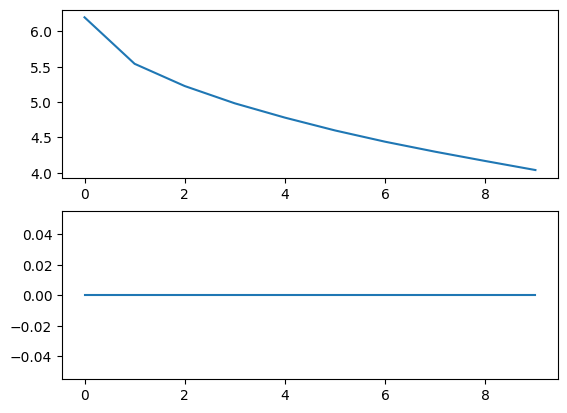

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2)
ax[0].plot(losses)
ax[1].plot(val_losses)

In [ ]:
translator.to("cpu")
torch.save({"loss": losses, "val_loss": val_losses,  "model": translator.state_dict()}, "translator.pt")
translator.to("cuda")

Seq2Seq(
  (encoder): SeqEncoder(
    (embed_layer): Embedding(20000, 128)
    (encoder): LSTM(128, 256, num_layers=2, batch_first=True)
  )
  (decoder): SeqDecoder(
    (embed_layer): Embedding(20000, 128)
    (decoder): LSTM(128, 256, num_layers=2, batch_first=True)
    (output_layer): Linear(in_features=256, out_features=20000, bias=True)
  )
)